In [16]:
# Firedrake coupled Saarelma–Connor solver tests
#
# Run from `tests/` (so `ROOT` points at the repo). Requires Firedrake +
# parent-class deps (OpenFUSIONToolkit, eqdsk/p-file inputs).

import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import os

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

INPUT_DIR = ROOT / "src" / "inputs" / "PT_Hmode"
MHD_FP = INPUT_DIR / "g189650.02500"
KPROF_FP = INPUT_DIR / "p189650.02500"

# `solver-firedrake.py` has a hyphen — load by file path.
_fd_spec = importlib.util.spec_from_file_location(
    "solver_firedrake",
    ROOT / "src" / "solver-firedrake.py",
)
_fd_mod = importlib.util.module_from_spec(_fd_spec)
_fd_spec.loader.exec_module(_fd_mod)
saarelma_connor_firedrake = _fd_mod.saarelma_connor_firedrake


In [17]:
# Shared solve kwargs (override per cell as needed).
initial_guess = "tanh"
ne_inner_bc = "neumann"
use_picard = False
SOLVE_KW = dict(
    x_res=200,
    fe_degree=2,
    use_picard=use_picard,
    picard_tol=1e-4,
    max_picard=100,
    relax=0.5,
    initial_guess=initial_guess,
    ne_inner_bc=ne_inner_bc,   # Saarelma A7 default; see dirichlet comparison below
    linear_solver="lu",      # or "gamg" for GMRES + algebraic multigrid on J
    verbose=False,
)

In [18]:
# Build the model once — the expensive flux-surface-averaging and equilibrium
# loading runs here only, not inside the loop.

# Scan size (each dimension has N points)
N = 5

# Scan parameters
alpha_crits = np.logspace(-1, 1, N)
C_KBMs = np.logspace(-1, 1.5, N)
De_chie_etgs = np.logspace(-1, 1.5, N)
nFC_x0s = np.logspace(14.5, 17.5, N)

# Static parameters
P_tot_e = 5e6 # W, total heating power given to electrons (can be assumed to be half the total heating power according to S. Saarelma et al 2023 Nucl. Fusion 63 052002), will be read from TokTox
solve_res = 200

# Output data and files
success_fp = 'success_PTHmode.txt'
failure_fp = 'failure_PTHmode.txt'
error_messages_fp = 'error_messages_PTHmode.txt'
with open(success_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(failure_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(error_messages_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner, message\n")
ne_success_fp = 'scan_success_PTHmode'
verbose = False

base_model = saarelma_connor_firedrake(
        P_tot_e     = P_tot_e,
        alpha_crit  = round(float(alpha_crits[0]), 3),
        C_KBM       = round(float(C_KBMs[0]), 3),
        De_chie_etg = round(float(De_chie_etgs[0]), 3),
        nFC_x0      = round(float(nFC_x0s[0]), 3),
        mhd_fp      = MHD_FP,
        kprof_fp    = KPROF_FP,
        verbose     = verbose,
        # psi_N_inner_boundary = 0.85, # set to None to use adaptive inner boundary method
)
print("Base model built.")

Base model built.


In [19]:
# Clear outputs from any previous scan (including appended failure logs).
for file in os.listdir(ne_success_fp):
    os.remove(os.path.join(ne_success_fp, file))
os.remove(success_fp)
os.remove(failure_fp)
os.remove(error_messages_fp)
with open(success_fp, "w") as f:
    f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(failure_fp, "w") as f:
    f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(error_messages_fp, "w") as f:
    f.write("alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner, message\n")

# run scan: for each (alpha_crit, C_KBM, De_chie_etg, nFC_x0) we recompute
# the valid range of psi_N_inner_boundary from the slope-zero inner limit to
# the nFC/nCX-threshold outer limit, then sample n_psi_inner_pts boundaries.
# n_iter = 0
i=0
for alpha_crit in alpha_crits:
        j=0
        for C_KBM in C_KBMs:
                k=0
                for De_chie_etg in De_chie_etgs:
                        l=0
                        for nFC_x0 in nFC_x0s:
                                ac = round(float(alpha_crit), 3)
                                ck = round(float(C_KBM), 3)
                                de = round(float(De_chie_etg), 3)
                                nf = round(float(nFC_x0), 3)

                                # Step 1: apply free params with adaptive thresholds active so
                                # inner_boundary_limits can compute the outer limit correctly.
                                base_model.update_free_params(
                                        alpha_crit    = ac,
                                        C_KBM         = ck,
                                        De_chie_etg   = de,
                                        nFC_x0        = nf,
                                )

                                # psi_scan = np.linspace(0.87, 0.94, N)
                                psi_scan = [0.85]

                                m=0
                                for psi_b in psi_scan:
                                        psi_val = round(float(psi_b), 4)
                                        try:
                                                base_model.update_free_params(
                                                        alpha_crit            = ac,
                                                        C_KBM                 = ck,
                                                        De_chie_etg           = de,
                                                        nFC_x0                = nf,
                                                        psi_N_inner_boundary  = psi_val,
                                                )
                                                x_sol, ne_sol, nFC_sol, nCX_sol = base_model.solve_firedrake(**SOLVE_KW)
                                                sol = {'x': x_sol, 'y': ne_sol, 'nFC': nFC_sol, 'nCX': nCX_sol}
                                        except Exception as e: # run fails
                                                with open(failure_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}\n")
                                                with open(error_messages_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}, {e}\n")
                                                m+=1
                                        else: # run works
                                                with open(success_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}\n")
                                                np.save(f'{ne_success_fp}/ne_a{ac}_C{ck}_D{de}_n{nf}_b{psi_val:.4f}', sol, allow_pickle=True)
                                                m+=1
                                        # n_iter += 1
                                        # if n_iter % 10 == 0: # RAM tracker
                                        #         gc.collect()
                                        #         print(f"  [{n_iter} iters] peak RAM ~ {_ram_mb():.0f} MB")
                                l+=1
                                # print(f"Completed {l} of {len(nFC_x0s)} nFC_x0s  [psi_N range: {psi_scan[0]:.3f}..{psi_scan[-1]:.3f}]") # progress logging
                        k+=1
                        # print(f"Completed {k} of {len(De_chie_etgs)} De_chie_etgs") # progress logging
                j+=1
                # print(f"Completed {j} of {len(C_KBMs)} C_KBMs") # progress logging
        i+=1
        print(f"Completed {i} of {len(alpha_crits)} alpha_crits") # progress logging

Completed 1 of 5 alpha_crits
Completed 2 of 5 alpha_crits
Completed 3 of 5 alpha_crits
Completed 4 of 5 alpha_crits
Completed 5 of 5 alpha_crits


Experimental p-file peak n_e: 8.330e+19 m^-3
Unique 5D scan points: 625 (expect up to 3125 = 3125); 625 succeeded


/var/folders/r6/8r1cpqbn0wq7td3h8x19h3kh0000gq/T/ipykernel_54467/3199251183.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


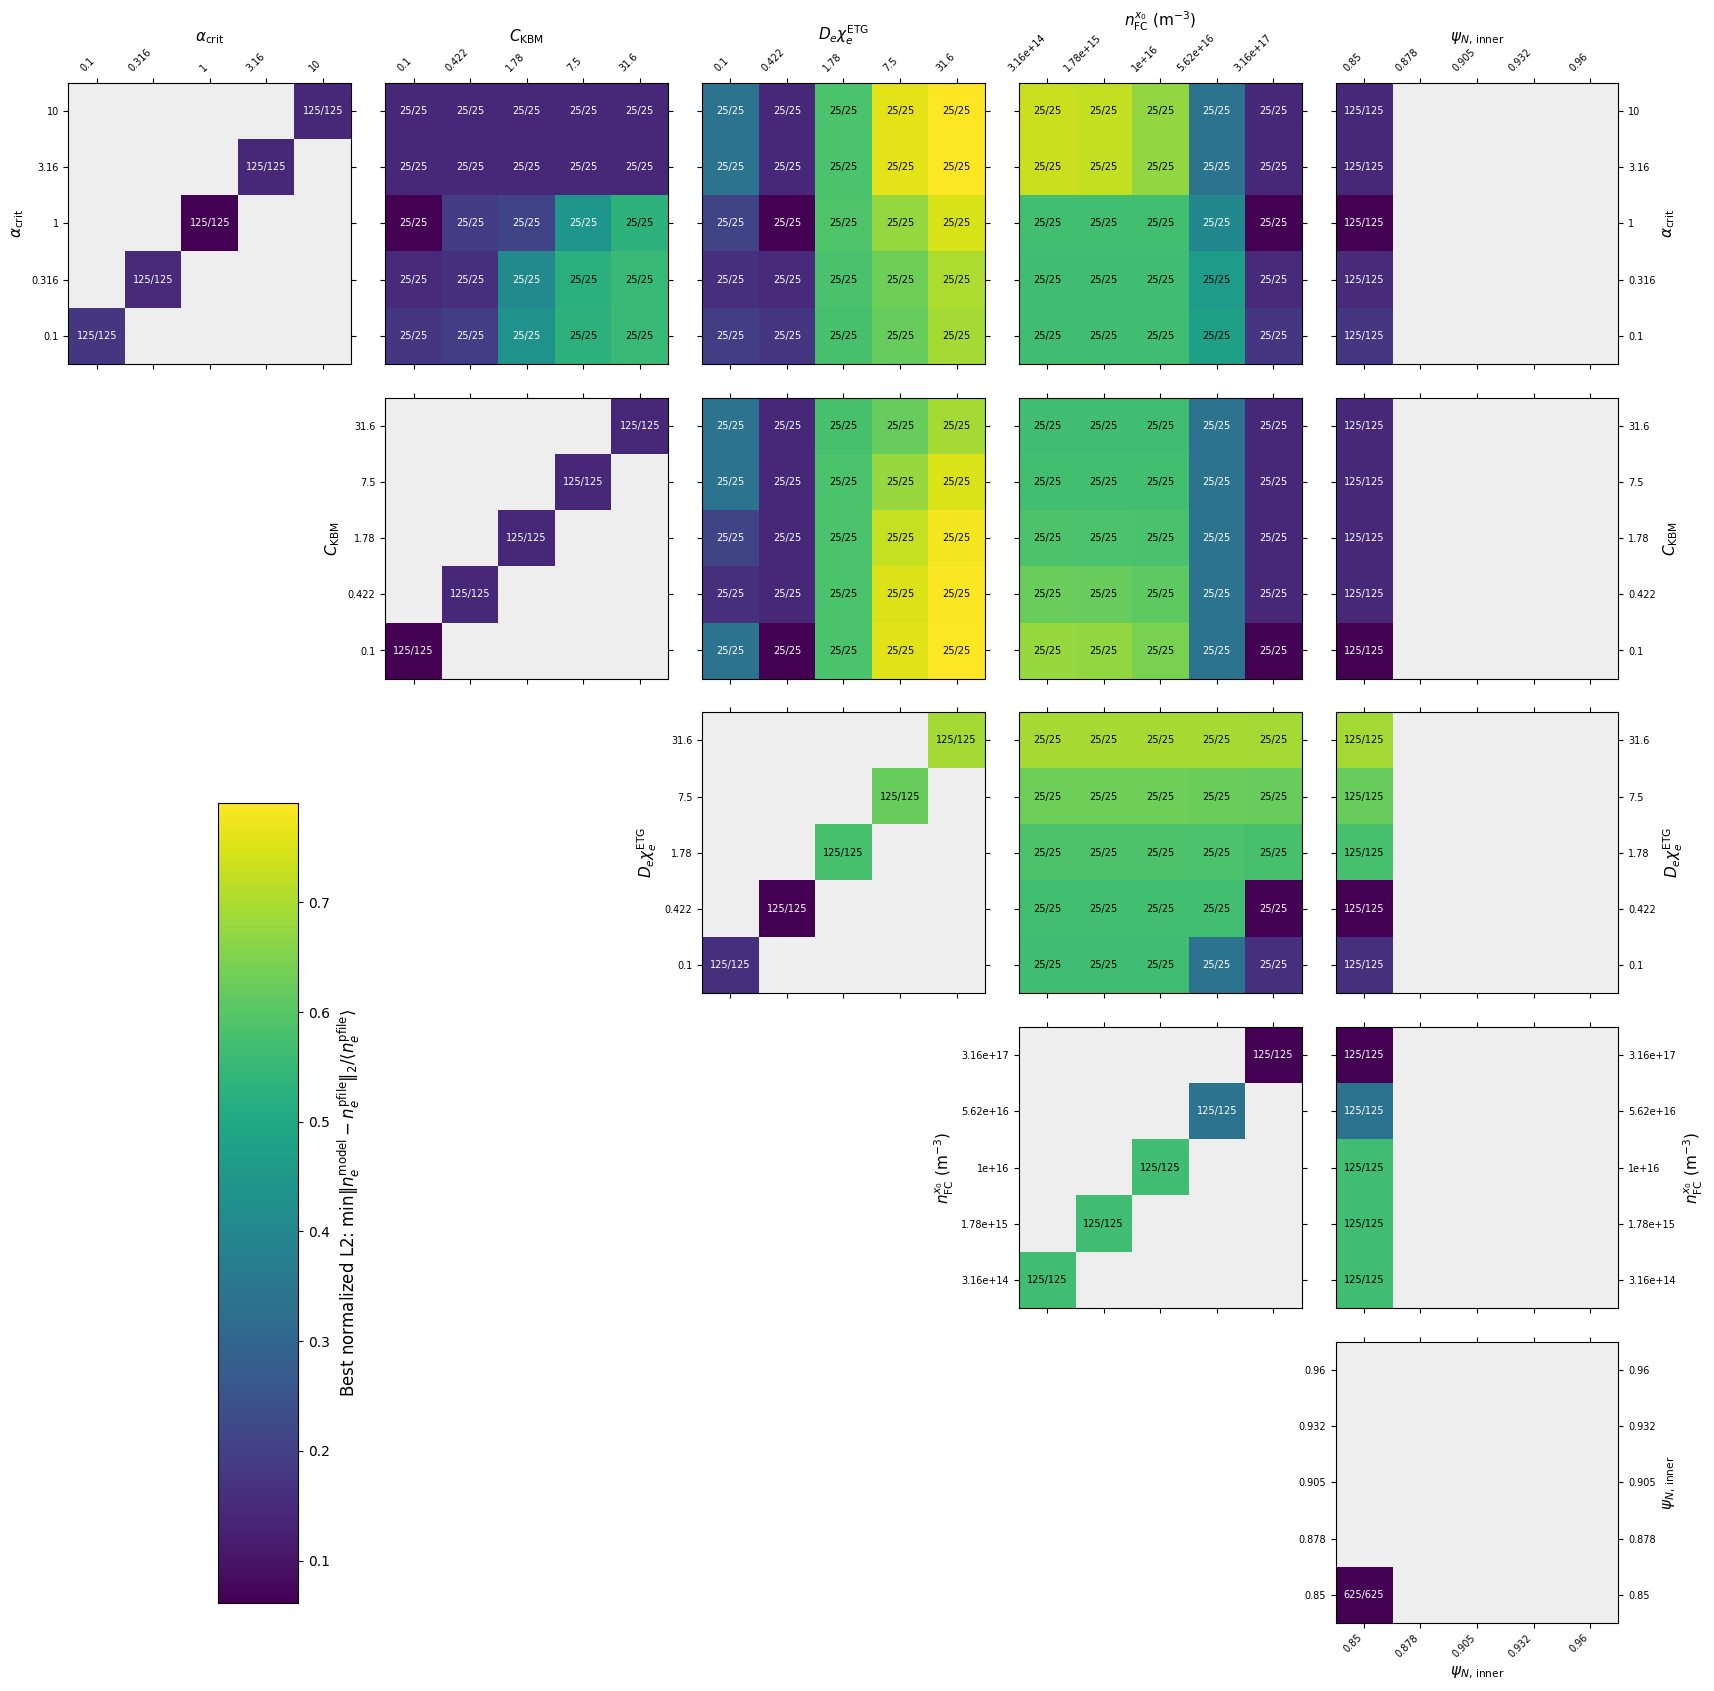

In [20]:
from matplotlib.colors import Normalize
import csv
import re
from pathlib import Path
from scipy.interpolate import interp1d

scan_dir = Path(ne_success_fp)
pattern = re.compile(r"_([a-zA-Z])([\d.eE+-]+)")

# 1. Peak density from the experimental p-file (m^-3)
def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if '3 N Z A' in line:
                break
            if line.startswith('201'):
                in_ne_block = 'ne(10^20/m^3)' in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20  # m^-3

psi_pfile, ne_pfile = read_pfile_ne(KPROF_FP)
peak_pfile = ne_pfile.max()
print(f"Experimental p-file peak n_e: {peak_pfile:.3e} m^-3")

# Build psi_N -> x mapping once (reused in cell 8)
ref = saarelma_connor_firedrake(
    P_tot_e=P_tot_e,
    alpha_crit=alpha_crits[0],
    C_KBM=C_KBMs[0],
    De_chie_etg=De_chie_etgs[0],
    nFC_x0=nFC_x0s[0],
    mhd_fp=MHD_FP,
    kprof_fp=KPROF_FP,
    verbose=False,
)
psi_to_x = interp1d(ref.psi_N_pres, ref.r_psi - ref.r_psi[-1],
                    kind='linear', bounds_error=False, fill_value='extrapolate')
# Inverse map for the secondary axis (x in meters -> psi_N).
x_to_psi = interp1d(ref.r_psi - ref.r_psi[-1], ref.psi_N_pres,
                    kind='linear', bounds_error=False, fill_value='extrapolate')

# Experimental ne mapped to x
x_pfile = psi_to_x(psi_pfile)


# Recompute normalized L2 for successful runs so this cell only depends on the
# earlier p-file mapping variables from cell 7 (psi_to_x, psi_pfile, ne_pfile,
# scan_dir, pattern).
psi_ped_grid = np.linspace(0.85, 1.0, 200)
x_ped_grid = psi_to_x(psi_ped_grid)
ne_pfile_on_ped = interp1d(psi_pfile, ne_pfile, kind='linear',
                           bounds_error=False, fill_value='extrapolate')(psi_ped_grid)
mean_ne_pfile = float(np.mean(ne_pfile_on_ped))

success_records = []  # alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_inner, normalized_l2
for npy_path in scan_dir.glob("ne_*.npy"):
    pairs = pattern.findall(npy_path.stem)
    params = {letter: float(num) for letter, num in pairs}
    sol = np.load(npy_path, allow_pickle=True).item()
    ne_pred_on_ped = interp1d(sol['x'], sol['y'], kind='linear',
                              bounds_error=False, fill_value='extrapolate')(x_ped_grid)
    l2 = np.sqrt(np.mean((ne_pred_on_ped - ne_pfile_on_ped) ** 2))
    success_records.append([
        params.get('a'), params.get('C'), params.get('D'),
        params.get('n'), params.get('b'), l2 / mean_ne_pfile,
    ])
success_arr_summary = np.array(success_records)

failure_records = []
with open(failure_fp, newline="") as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        failure_records.append([float(x.strip()) for x in row])
failure_arr_summary = np.array(failure_records) if failure_records else np.empty((0, 5))

panel_names = ['alpha_crit', 'C_KBM', 'De_chie_etg', 'nFC_x0', 'psi_inner']
panel_labels = [r'$\alpha_{\mathrm{crit}}$',
                r'$C_{\mathrm{KBM}}$',
                r'$D_{e}\chi_{e}^{\mathrm{ETG}}$',
                r'$n_{\mathrm{FC}}^{x_0}$ (m$^{-3}$)',
                r'$\psi_{N,\,\mathrm{inner}}$']

all_params = success_arr_summary[:, :5]
if failure_arr_summary.size:
    all_params = np.vstack([all_params, failure_arr_summary])

# Fixed scan grids (match the scan loop: logspace for free params, linspace for psi_N).
param_values = [
    np.round(alpha_crits.astype(float), 3),
    np.round(C_KBMs.astype(float), 3),
    np.round(De_chie_etgs.astype(float), 3),
    np.round(nFC_x0s.astype(float), 3),
    np.round(np.linspace(0.85, 0.96, N), 3),
]

def _record_to_bins(record5):
    """Map one run to 5 scan-bin indices, or None if any parameter is off-grid."""
    bins = []
    for d in range(5):
        grid = param_values[d]
        val = float(record5[d])
        i = int(np.argmin(np.abs(grid - val)))
        if d == 4:
            on_grid = np.isclose(grid[i], val, atol=5e-4)
        elif d == 3:
            on_grid = np.isclose(grid[i], val, rtol=1e-3)
        else:
            on_grid = np.isclose(grid[i], val, rtol=0, atol=1e-6)
        if not on_grid:
            return None
        bins.append(i)
    return tuple(bins)

# One entry per unique 5D parameter combination (dedupe repeated log / scan lines).
# successes overwrite failures for the same combination.
run_outcomes = {}
for record in success_arr_summary:
    bins5 = _record_to_bins(record[:5])
    if bins5 is None:
        continue
    run_outcomes[bins5] = {"success": True, "l2": float(record[5])}

for record in failure_arr_summary:
    bins5 = _record_to_bins(record[:5])
    if bins5 is None:
        continue
    run_outcomes.setdefault(bins5, {"success": False})

print(
    f"Unique 5D scan points: {len(run_outcomes)} "
    f"(expect up to {N**5} = {N**5}); "
    f"{sum(1 for o in run_outcomes.values() if o['success'])} succeeded"
)

cmap = plt.get_cmap('viridis').copy()
cmap.set_bad('#eeeeee')

# Aggregate best L2 per 2D bin first; color limits match what is actually plotted.
panel_grids = {}
for row in range(5):
    for col in range(5):
        if row > col:
            continue
        x_vals = param_values[col]
        y_vals = param_values[row]
        best_l2 = np.full((len(y_vals), len(x_vals)), np.nan)
        n_success = np.zeros((len(y_vals), len(x_vals)), dtype=int)
        n_total = np.zeros((len(y_vals), len(x_vals)), dtype=int)
        for bins5, outcome in run_outcomes.items():
            yi, xi = bins5[row], bins5[col]
            if row == col and yi != xi:
                continue
            n_total[yi, xi] += 1
            if outcome["success"]:
                n_success[yi, xi] += 1
                l2 = outcome["l2"]
                best_l2[yi, xi] = l2 if np.isnan(best_l2[yi, xi]) else min(best_l2[yi, xi], l2)
        panel_grids[(row, col)] = (best_l2, n_success, n_total, x_vals, y_vals)

plotted_l2 = np.concatenate([
    np.ravel(g[0][np.isfinite(g[0])]) for g in panel_grids.values()
])
vmin = float(plotted_l2.min())
vmax = float(plotted_l2.max())
norm = Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(5, 5, figsize=(20, 20),
                         gridspec_kw=dict(wspace=0.12, hspace=0.12))

for row in range(5):
    for col in range(5):
        ax = axes[row, col]
        if row > col:
            ax.set_visible(False)
            continue

        best_l2, n_success, n_total, x_vals, y_vals = panel_grids[(row, col)]

        im = ax.imshow(np.ma.masked_invalid(best_l2), origin='lower',
                       aspect='auto', cmap=cmap, norm=norm)

        # Annotate each attempted 2D bin. White text is used on darker cells;
        # black text remains readable on light/empty cells.
        for yi in range(len(y_vals)):
            for xi in range(len(x_vals)):
                if n_total[yi, xi] == 0:
                    continue
                if n_success[yi, xi] == 0:
                    ax.text(xi, yi, 'x', ha='center', va='center',
                            color='0.35', fontsize=9, fontweight='bold')
                    continue
                color = 'white' if norm(best_l2[yi, xi]) < 0.55 else 'black'
                ax.text(xi, yi, f"{n_success[yi, xi]}/{n_total[yi, xi]}",
                        ha='center', va='center', color=color, fontsize=7)

        ax.set_xticks(range(len(x_vals)))
        ax.set_yticks(range(len(y_vals)))
        ax.set_xticklabels([f"{v:.3g}" for v in x_vals], rotation=45, ha='right')
        ax.set_yticklabels([f"{v:.3g}" for v in y_vals])

        # Upper triangle (row <= col): label the outer perimeter only.
        show_top_x = row == 0
        show_bottom_x = row == 4
        show_left_y = col == row
        show_right_y = col == 4

        ax.tick_params(axis='x', which='both', bottom=True, labelbottom=show_bottom_x,
                       top=True, labeltop=show_top_x, labelsize=7)
        ax.tick_params(axis='y', which='both', left=True, labelleft=show_left_y,
                       right=True, labelright=show_right_y, labelsize=7)

        if show_bottom_x:
            ax.set_xlabel(panel_labels[col], fontsize=11)
        if show_top_x:
            ax.xaxis.set_label_position('top')
            ax.set_xlabel(panel_labels[col], fontsize=11)
        if show_left_y:
            ax.set_ylabel(panel_labels[row], fontsize=11)
        if show_right_y:
            ax.yaxis.set_label_position('right')
            ax.set_ylabel(panel_labels[row], fontsize=11)

visible_axes = [axes[r, c] for r in range(5) for c in range(5) if r <= c]
# Lower-left of the figure (in the empty lower-triangle margin).
cbar_ax = fig.add_axes([0.2, 0.12, 0.04, 0.40])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_label(r'Best normalized L2: $\min \|n_e^{\mathrm{model}} - n_e^{\mathrm{pfile}}\|_2 / \langle n_e^{\mathrm{pfile}}\rangle$',
               fontsize=12)

# fig.suptitle(
#     f"Aggregated 2D projections of 5D scan for equilibrium {Path(mhd_fp).name}\n"
#     "cell text = converged / attempted for all combinations of the other three parameters",
#     fontsize=14, y=0.92,
# )
plt.tight_layout()
plt.show()

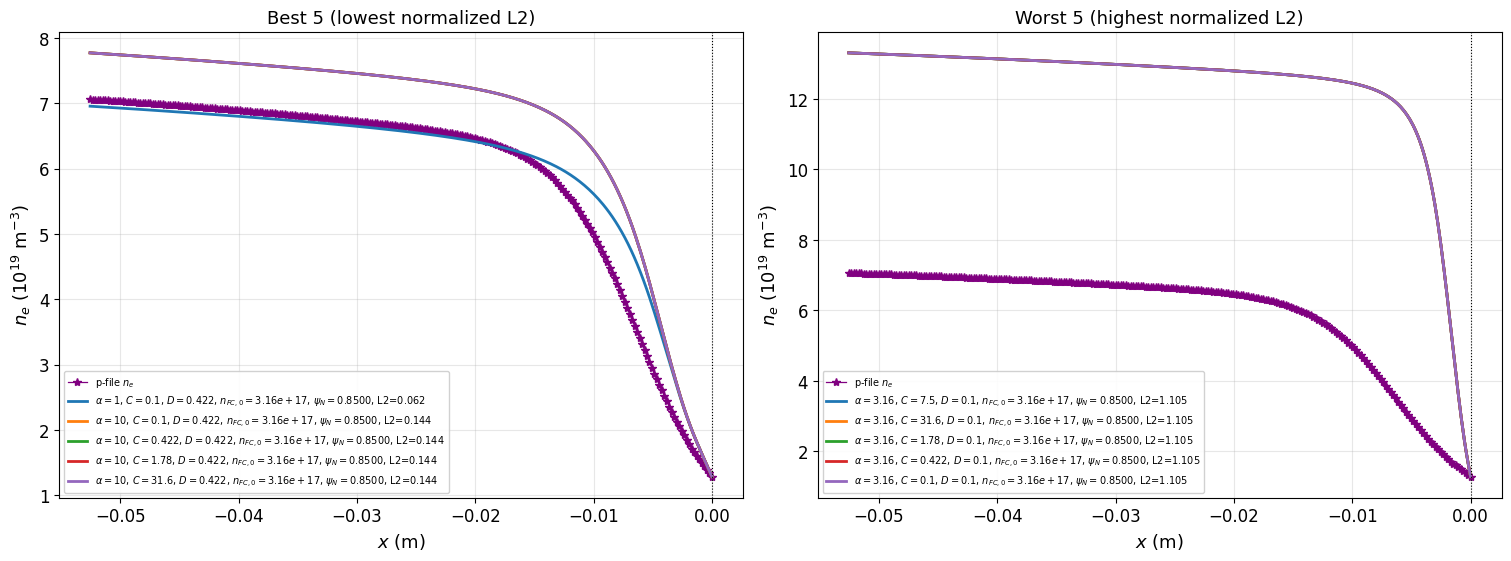

In [21]:
# Plot best 5 and worst 5 n_e profiles depending on L2 distance from p-file
profile_runs = []
for npy_path in sorted(scan_dir.glob("ne_*.npy")):
    pairs = pattern.findall(npy_path.stem)
    params = {letter: float(num) for letter, num in pairs}
    record5 = [params.get("a"), params.get("C"), params.get("D"),
               params.get("n"), params.get("b")]
    bins5 = _record_to_bins(record5)
    if bins5 is None:
        continue

    sol = np.load(npy_path, allow_pickle=True).item()
    x_sol = np.asarray(sol['x'], dtype=float)
    ne_sol = np.asarray(sol['y'], dtype=float)
    ne_pred_on_ped = interp1d(
        x_sol, ne_sol, kind="linear", bounds_error=False, fill_value="extrapolate",
    )(x_ped_grid)
    l2_norm = float(np.sqrt(np.mean((ne_pred_on_ped - ne_pfile_on_ped) ** 2)) / mean_ne_pfile)

    label = (
        rf"$\alpha={params['a']:.3g}$, $C={params['C']:.3g}$, $D={params['D']:.3g}$, "
        rf"$n_{{FC,0}}={params['n']:.2e}$, $\psi_N={params['b']:.4f}$, "
        rf"L2={l2_norm:.3f}"
    )
    entry = dict(l2=l2_norm, label=label, x=x_sol, ne=ne_sol, bins5=bins5)
    prev = next((r for r in profile_runs if r["bins5"] == bins5), None)
    if prev is None or l2_norm < prev["l2"]:
        if prev is not None:
            profile_runs.remove(prev)
        profile_runs.append(entry)

profile_runs.sort(key=lambda r: r["l2"])
n_show = min(5, len(profile_runs))
if n_show == 0:
    print("No on-grid successful scan profiles found — run the scan cell first.")
else:
    best = profile_runs[:n_show]
    worst = profile_runs[-n_show:][::-1]

    fig, (ax_best, ax_worst) = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
    for ax, subset, title in (
        (ax_best, best, f"Best {n_show} (lowest normalized L2)"),
        (ax_worst, worst, f"Worst {n_show} (highest normalized L2)"),
    ):
        x_lo = min(r["x"].min() for r in subset)
        x_hi = max(r["x"].max() for r in subset)
        x_plot = np.linspace(x_lo, x_hi, 250)
        psi_on_plot = x_to_psi(x_plot)
        ne_pfile_on_x = interp1d(
            psi_pfile, ne_pfile, kind="linear", bounds_error=False, fill_value="extrapolate",
        )(psi_on_plot)
        ax.plot(
            x_plot, ne_pfile_on_x / 1e19, "*-", color="purple", ms=6, lw=0.9,
            label="p-file $n_e$",
        )

        for i, run in enumerate(subset):
            ax.plot(
                run["x"], run["ne"] / 1e19,
                color=plt.cm.tab10(i), lw=2.0, label=run["label"],
            )
        ax.axvline(0, color="k", ls=":", lw=0.8)
        ax.set_xlabel(r"$x$ (m)", fontsize=13)
        ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)", fontsize=13)
        ax.set_title(title, fontsize=13)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=12)
        ax.legend(fontsize=7, loc="lower left", framealpha=0.9)

    plt.savefig("compare_solvers_results_158040_03000/ne_"+ne_inner_bc+f"_{str(use_picard)}_"+initial_guess+".png", dpi=300)
    plt.show()



Parameter combination:  $\alpha=1$, $C=0.1$, $D=0.422$, $n_{FC,0}=3.16e+17$, $\psi_N=0.8500$, L2=0.062 L2:  0.061535128469341574
Parameter combination:  $\alpha=10$, $C=0.1$, $D=0.422$, $n_{FC,0}=3.16e+17$, $\psi_N=0.8500$, L2=0.144 L2:  0.1440008453799039
Parameter combination:  $\alpha=10$, $C=0.422$, $D=0.422$, $n_{FC,0}=3.16e+17$, $\psi_N=0.8500$, L2=0.144 L2:  0.1440008453799039
Parameter combination:  $\alpha=10$, $C=1.78$, $D=0.422$, $n_{FC,0}=3.16e+17$, $\psi_N=0.8500$, L2=0.144 L2:  0.1440008453799039
Parameter combination:  $\alpha=10$, $C=31.6$, $D=0.422$, $n_{FC,0}=3.16e+17$, $\psi_N=0.8500$, L2=0.144 L2:  0.1440008453799039
Parameter combination:  $\alpha=10$, $C=7.5$, $D=0.422$, $n_{FC,0}=3.16e+17$, $\psi_N=0.8500$, L2=0.144 L2:  0.1440008453799039
Parameter combination:  $\alpha=3.16$, $C=0.1$, $D=0.422$, $n_{FC,0}=3.16e+17$, $\psi_N=0.8500$, L2=0.144 L2:  0.1440008453799039
Parameter combination:  $\alpha=3.16$, $C=0.422$, $D=0.422$, $n_{FC,0}=3.16e+17$, $\psi_N=0.8500$

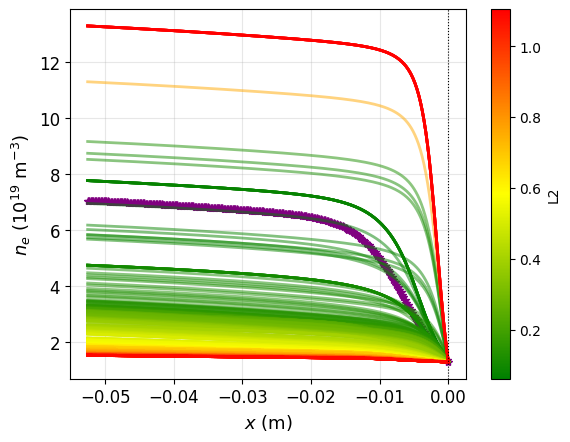

In [22]:
# Plot all profiles on a color gradient
profile_runs = []
for npy_path in sorted(scan_dir.glob("ne_*.npy")):
    pairs = pattern.findall(npy_path.stem)
    params = {letter: float(num) for letter, num in pairs}
    record5 = [params.get("a"), params.get("C"), params.get("D"),
               params.get("n"), params.get("b")]
    bins5 = _record_to_bins(record5)
    if bins5 is None:
        continue

    sol = np.load(npy_path, allow_pickle=True).item()
    x_sol = np.asarray(sol['x'], dtype=float)
    ne_sol = np.asarray(sol['y'], dtype=float)
    ne_pred_on_ped = interp1d(
        x_sol, ne_sol, kind="linear", bounds_error=False, fill_value="extrapolate",
    )(x_ped_grid)
    l2_norm = float(np.sqrt(np.mean((ne_pred_on_ped - ne_pfile_on_ped) ** 2)) / mean_ne_pfile)

    label = (
        rf"$\alpha={params['a']:.3g}$, $C={params['C']:.3g}$, $D={params['D']:.3g}$, "
        rf"$n_{{FC,0}}={params['n']:.2e}$, $\psi_N={params['b']:.4f}$, "
        rf"L2={l2_norm:.3f}"
    )
    entry = dict(l2=l2_norm, label=label, x=x_sol, ne=ne_sol, bins5=bins5)
    prev = next((r for r in profile_runs if r["bins5"] == bins5), None)
    if prev is None or l2_norm < prev["l2"]:
        if prev is not None:
            profile_runs.remove(prev)
        profile_runs.append(entry)

profile_runs.sort(key=lambda r: r["l2"]) # best to worst profiles in L2 order
n_show = len(profile_runs)
if n_show == 0:
    print("No on-grid successful scan profiles found — run the scan cell first.")
else:
    # best = profile_runs[:n_show]
    # worst = profile_runs[-n_show:][::-1]

    # fig, (ax_best, ax_worst) = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
    # for ax, subset, title in (
    #     (ax_best, best, f"Best {n_show} (lowest normalized L2)"),
    #     (ax_worst, worst, f"Worst {n_show} (highest normalized L2)"),
    # ):
    fig, ax = plt.subplots()
    x_lo = min(r["x"].min() for r in profile_runs)
    x_hi = max(r["x"].max() for r in profile_runs)
    x_plot = np.linspace(x_lo, x_hi, 250)
    psi_on_plot = x_to_psi(x_plot)
    ne_pfile_on_x = interp1d(
        psi_pfile, ne_pfile, kind="linear", bounds_error=False, fill_value="extrapolate",
    )(psi_on_plot)
    ax.plot(
        x_plot, ne_pfile_on_x / 1e19, "*-", color="purple", ms=6, lw=0.9,
        label="p-file $n_e$",
    )

    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.colors import Normalize
    from matplotlib.cm import ScalarMappable

    l2_values = [run["l2"] for run in profile_runs]
    vmin = min(l2_values)
    vmax = max(l2_values)

    cmap = plt.get_cmap("RdYlGn_r") # Or your custom green-to-red cmap
    norm = Normalize(vmin=vmin, vmax=vmax)
    # cmap = LinearSegmentedColormap.from_list("red_to_green", ["red", "green"])
    num_runs = len(profile_runs)
    cmap = LinearSegmentedColormap.from_list('custom', ['green', 'yellow', 'red'])
    for i, run in enumerate(profile_runs):
        fraction = i / (num_runs - 1) if num_runs > 1 else 0.5
        ax.plot(
            run["x"], run["ne"] / 1e19,
            color=cmap(fraction), lw=2.0, label=run["label"], alpha=0.5
        )
        print("Parameter combination: ", run["label"], "L2: ", run["l2"])
    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.set_xlabel(r"$x$ (m)", fontsize=13)
    ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=12)
    # 4. Create a ScalarMappable and add the colorbar to the figure
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) # This is required for the colorbar to render correctly

    # Add the colorbar to the figure, attached to your specific axes
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("L2") # Label the colorbar
    # ax.legend(fontsize=7, loc="lower left", framealpha=0.9)

    # plt.savefig("compare_solvers_results_158040_03000/ne_"+ne_inner_bc+f"_{str(use_picard)}_"+initial_guess+".png", dpi=300)
    # plt.show()



/var/folders/r6/8r1cpqbn0wq7td3h8x19h3kh0000gq/T/ipykernel_54467/3578359833.py:165: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.88)


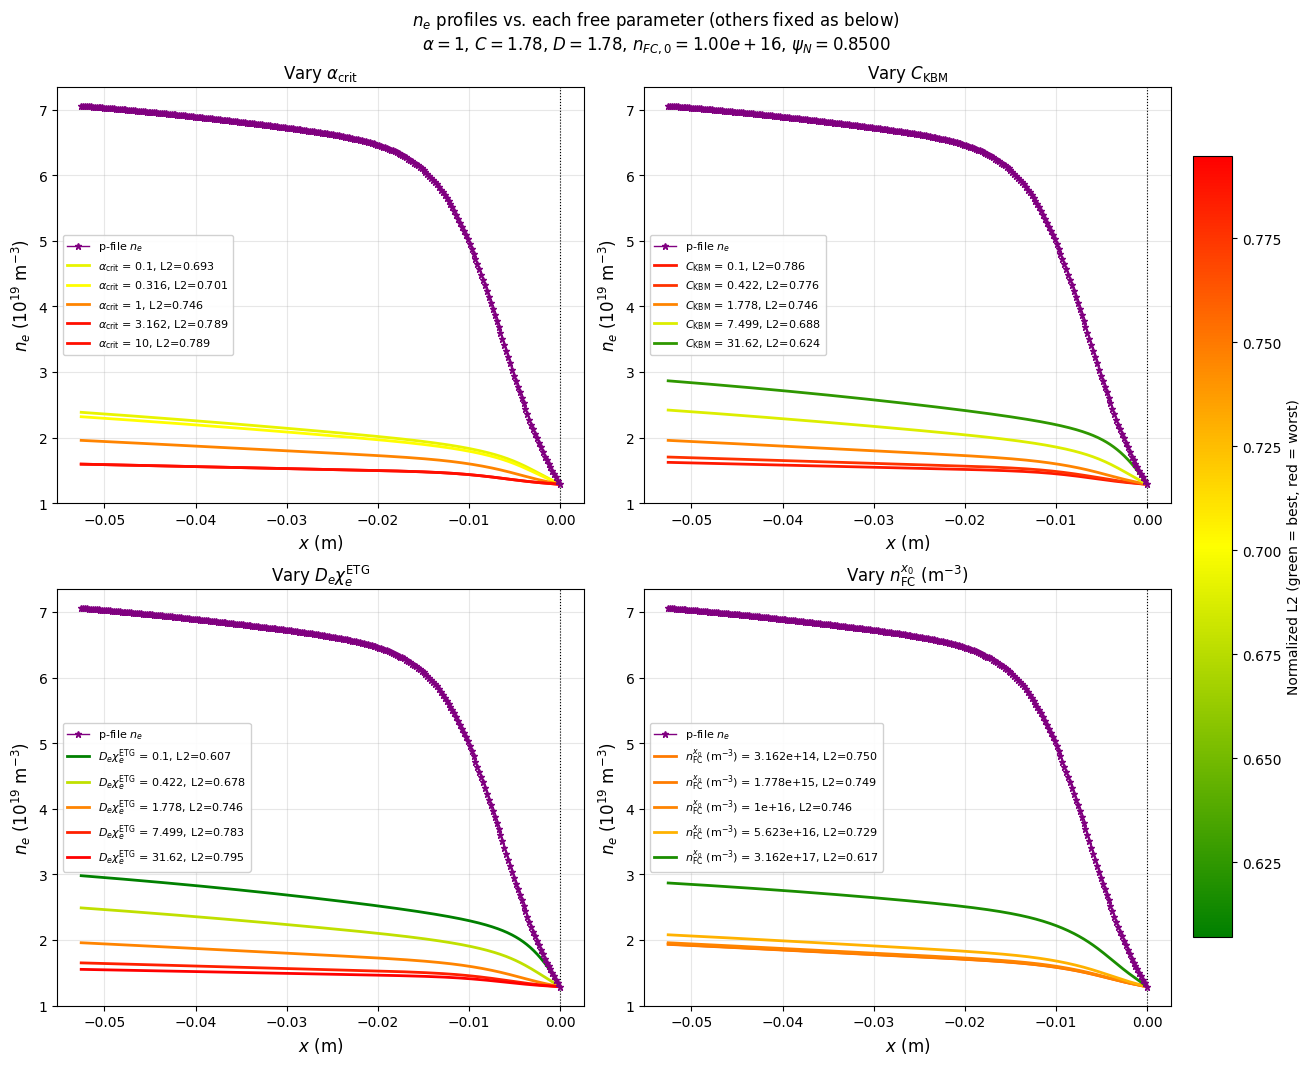

In [23]:
# Four-panel n_e profiles: sweep one free parameter; fix the other four explicitly (or None = default).
#
# Edit these: set a number to hold that parameter fixed in every panel; None = automatic default.
#   dims 0–3 default: midpoint of the cell-2 scan grid (rounded like np.save filenames)
#   dim 4 default: psi_N value(s) found in scan_success_PTHmode/ne_*.npy
FIXED_ALPHA_CRIT = None      # e.g. 10.0
FIXED_C_KBM = None           # e.g. 1.778
FIXED_DE_CHIE_ETG = None     # e.g. 1.778
FIXED_NFC_X0 = None          # e.g. 1e17
FIXED_PSI_N_INNER = 0.85     # e.g. 0.85

# Scan grids (for matching varied parameter values in filenames; must match cell 2).
scan_arrays = [
    np.round(alpha_crits.astype(float), 3),
    np.round(C_KBMs.astype(float), 3),
    np.round(De_chie_etgs.astype(float), 3),
    np.round(nFC_x0s.astype(float), 3),
    None,
]
_psi_in_files = sorted({
    float(params["b"])
    for p in scan_dir.glob("ne_*.npy")
    for params in [{letter: float(num) for letter, num in pattern.findall(p.stem)}]
})
if not _psi_in_files:
    raise RuntimeError("No ne_*.npy in scan_dir — run the scan cell first.")
scan_arrays[4] = np.array(_psi_in_files, dtype=float)

_fixed_user = [
    FIXED_ALPHA_CRIT,
    FIXED_C_KBM,
    FIXED_DE_CHIE_ETG,
    FIXED_NFC_X0,
    FIXED_PSI_N_INNER,
]

scan_labels = [
    r"$\alpha_{\mathrm{crit}}$",
    r"$C_{\mathrm{KBM}}$",
    r"$D_{e}\chi_{e}^{\mathrm{ETG}}$",
    r"$n_{\mathrm{FC}}^{x_0}$ (m$^{-3}$)",
]
i_mid = N // 2

def _saved_param(val, dim):
    """Round like the scan loop / np.save filenames."""
    if dim == 4:
        return round(float(val), 4)
    return round(float(val), 3)

def _param_close(val, target, dim):
    if dim == 3:
        return np.isclose(val, target, rtol=1e-3)
    if dim == 4:
        return np.isclose(val, target, atol=5e-4)
    return np.isclose(val, target, rtol=0, atol=1e-6)

# Resolved targets used when filtering ne_*.npy (after _saved_param rounding).
fixed_targets = []
for j, user_val in enumerate(_fixed_user):
    if user_val is not None:
        fixed_targets.append(_saved_param(user_val, j))
    elif j == 4:
        fixed_targets.append(float(scan_arrays[4][len(scan_arrays[4]) // 2]))
    else:
        fixed_targets.append(_saved_param(scan_arrays[j][i_mid], j))

def _fixed_target(j):
    return fixed_targets[j]


def _load_profiles_for_slice(vary_dim):
    """Runs with other parameters at fixed_targets; vary_dim sweeps scan_arrays[vary_dim]."""
    runs = []
    for npy_path in sorted(scan_dir.glob("ne_*.npy")):
        pairs = pattern.findall(npy_path.stem)
        params = {letter: float(num) for letter, num in pairs}
        record = [params["a"], params["C"], params["D"], params["n"], params["b"]]
        if not all(
            _param_close(record[j], _fixed_target(j), j)
            for j in range(5)
            if j != vary_dim
        ):
            continue
        j_vary = int(np.argmin(np.abs(scan_arrays[vary_dim] - record[vary_dim])))
        if not _param_close(record[vary_dim], _saved_param(scan_arrays[vary_dim][j_vary], vary_dim), vary_dim):
            continue
        sol = np.load(npy_path, allow_pickle=True).item()
        x_sol = np.asarray(sol["x"], dtype=float)
        ne_sol = np.asarray(sol["y"], dtype=float)
        ne_pred_on_ped = interp1d(
            x_sol, ne_sol, kind="linear", bounds_error=False, fill_value="extrapolate",
        )(x_ped_grid)
        l2_norm = float(
            np.sqrt(np.mean((ne_pred_on_ped - ne_pfile_on_ped) ** 2)) / mean_ne_pfile
        )
        runs.append({
            "idx": j_vary,
            "param_val": _saved_param(scan_arrays[vary_dim][j_vary], vary_dim),
            "x": x_sol,
            "ne": ne_sol,
            "l2": l2_norm,
        })
    runs.sort(key=lambda r: r["idx"])
    # One profile per scan index (keep first if duplicates).
    by_idx = {}
    for r in runs:
        by_idx.setdefault(r["idx"], r)
    return [by_idx[i] for i in sorted(by_idx)]

slices = [_load_profiles_for_slice(d) for d in range(4)]
if not any(slices):
    print("No matching scan profiles — run the scan cell first.")
else:
    from matplotlib.colors import LinearSegmentedColormap, Normalize
    from matplotlib.cm import ScalarMappable

    fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
    all_l2 = [r["l2"] for sl in slices for r in sl]
    l2_norm_obj = Normalize(vmin=min(all_l2), vmax=max(all_l2))
    # Worst L2 (high) → red; best L2 (low) → green
    l2_cmap = LinearSegmentedColormap.from_list(
        "l2_worst_to_best", ["green", "yellow", "red"]
    )
    fixed_str = (
        rf"$\alpha={fixed_targets[0]:.3g}$, "
        rf"$C={fixed_targets[1]:.3g}$, "
        rf"$D={fixed_targets[2]:.3g}$, "
        rf"$n_{{FC,0}}={fixed_targets[3]:.2e}$, "
        rf"$\psi_N={fixed_targets[4]:.4f}$"
    )

    all_x = [r["x"] for sl in slices for r in sl]
    x_lo = min(x.min() for x in all_x)
    x_hi = max(x.max() for x in all_x)
    x_plot = np.linspace(x_lo, x_hi, 250)
    psi_on_plot = x_to_psi(x_plot)
    ne_pfile_on_x = interp1d(
        psi_pfile, ne_pfile, kind="linear", bounds_error=False, fill_value="extrapolate",
    )(psi_on_plot)

    for ax, runs, label in zip(axes.ravel(), slices, scan_labels):
        ax.plot(
            x_plot, ne_pfile_on_x / 1e19, "*-", color="purple", ms=5, lw=1.0,
            label="p-file $n_e$", zorder=10,
        )
        for run in runs:
            ax.plot(
                run["x"], run["ne"] / 1e19,
                color=l2_cmap(l2_norm_obj(run["l2"])), lw=2.0,
                label=f"{label} = {run['param_val']:.4g}, L2={run['l2']:.3f}",
            )
        ax.axvline(0, color="k", ls=":", lw=0.8)
        ax.set_xlabel(r"$x$ (m)", fontsize=12)
        ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)", fontsize=12)
        ax.set_title(f"Vary {label}", fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best", framealpha=0.9)

    sm = ScalarMappable(cmap=l2_cmap, norm=l2_norm_obj)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel(), shrink=0.85, pad=0.02)
    cbar.set_label(r"Normalized L2 (green = best, red = worst)")
    # Leave headroom for suptitle (run after colorbar so layout includes it).
    fig.subplots_adjust(top=0.88)
    fig.suptitle(
        f"$n_e$ profiles vs. each free parameter (others fixed as below)\n{fixed_str}",
        fontsize=12, y=1.05,
    )
    plt.show()


In [ ]:
# Scan ncx_x0_ratio
ncx_x0_ratios = np.logspace(-2, 2, 10)


# Clear outputs from any previous scan (including appended failure logs).
for file in os.listdir(ne_success_fp):
    os.remove(os.path.join(ne_success_fp, file))
os.remove(success_fp)
os.remove(failure_fp)
os.remove(error_messages_fp)
with open(success_fp, "w") as f:
    f.write("ncx_x0_ratio\n")
with open(failure_fp, "w") as f:
    f.write("ncx_x0_ratio\n")
with open(error_messages_fp, "w") as f:
    f.write("ncx_x0_ratio, message\n")

# run scan: for each (alpha_crit, C_KBM, De_chie_etg, nFC_x0) we recompute
# the valid range of psi_N_inner_boundary from the slope-zero inner limit to
# the nFC/nCX-threshold outer limit, then sample n_psi_inner_pts boundaries.
ac = alpha_crits[0]
ck = C_KBMs[0]
de = De_chie_etgs[0]
nf = nFC_x0s[0]
psi_val = 0.85
i=0
for ncx_x0_ratio in ncx_x0_ratios:
        try:
                base_model.update_free_params(
                        alpha_crit            = ac,
                        C_KBM                 = ck,
                        De_chie_etg           = de,
                        nFC_x0                = nf,
                        psi_N_inner_boundary  = psi_val,
                        ncx_x0_ratio          = ncx_x0_ratio,
                )
                x_sol, ne_sol, nFC_sol, nCX_sol = base_model.solve_firedrake(**SOLVE_KW)
                sol = {'x': x_sol, 'y': ne_sol, 'nFC': nFC_sol, 'nCX': nCX_sol}
        except Exception as e: # run fails
                with open(failure_fp, 'a') as f:
                        f.write(f"{ncx_x0_ratio}\n")
                with open(error_messages_fp, 'a') as f:
                        f.write(f"{ncx_x0_ratio}, {e}\n")
        else: # run works
                with open(success_fp, 'a') as f:
                        f.write(f"{ncx_x0_ratio}\n")
                np.save(f'{ne_success_fp}/ne_ncx_x0_ratio{ncx_x0_ratio}', sol, allow_pickle=True)
        i+=1

In [ ]:
# Plot n_e profiles from ncx_x0_ratio scan (standalone — run from tests/firedrake_solver/).
import importlib.util
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
INPUT_DIR = ROOT / "src" / "inputs" / "PT_Hmode"
MHD_FP = INPUT_DIR / "g189650.02500"
KPROF_FP = INPUT_DIR / "p189650.02500"
ne_success_fp = "scan_success_PTHmode"

_fd_spec = importlib.util.spec_from_file_location(
    "solver_firedrake", ROOT / "src" / "solver-firedrake.py",
)
_fd_mod = importlib.util.module_from_spec(_fd_spec)
_fd_spec.loader.exec_module(_fd_mod)
saarelma_connor_firedrake = _fd_mod.saarelma_connor_firedrake


def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if "3 N Z A" in line:
                break
            if line.startswith("201"):
                in_ne_block = "ne(10^20/m^3)" in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20


psi_pfile, ne_pfile = read_pfile_ne(KPROF_FP)

# Match fixed parameters used in the ncx_x0_ratio scan cell.
N = 5
P_tot_e = 5e6
alpha_crits = np.logspace(-2, 1.5, N)
C_KBMs = np.logspace(-1, 1.5, N)
De_chie_etgs = np.logspace(-1, 1.5, N)
nFC_x0s = np.logspace(15.5, 18.5, N)
psi_scan = np.linspace(0.85, 0.94, N)
ac, ck, de, nf, psi_val = (
    alpha_crits[0], C_KBMs[0], De_chie_etgs[0], nFC_x0s[0], psi_scan[0],
)

ref = saarelma_connor_firedrake(
    P_tot_e=P_tot_e,
    alpha_crit=round(float(ac), 3),
    C_KBM=round(float(ck), 3),
    De_chie_etg=round(float(de), 3),
    nFC_x0=round(float(nFC_x0s[0]), 3),
    mhd_fp=MHD_FP,
    kprof_fp=KPROF_FP,
    verbose=False,
)
x_to_psi = interp1d(
    ref.r_psi - ref.r_psi[-1], ref.psi_N_pres,
    kind="linear", bounds_error=False, fill_value="extrapolate",
)

ncx_scan_dir = Path(ne_success_fp)
ncx_pattern = re.compile(r"ne_ncx_x0_ratio([\d.eE+-]+)")

ncx_runs = []
for npy_path in sorted(ncx_scan_dir.glob("ne_ncx_x0_ratio*.npy")):
    m = ncx_pattern.match(npy_path.stem)
    if not m:
        continue
    ratio = float(m.group(1))
    sol = np.load(npy_path, allow_pickle=True).item()
    ncx_runs.append({
        "ratio": ratio,
        "x": np.asarray(sol["x"], dtype=float),
        "ne": np.asarray(sol["y"], dtype=float),
    })
ncx_runs.sort(key=lambda r: r["ratio"])

if not ncx_runs:
    print("No ncx_x0_ratio scan profiles found — run the scan cell first.")
else:
    fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
    x_lo = min(r["x"].min() for r in ncx_runs)
    x_hi = max(r["x"].max() for r in ncx_runs)
    x_plot = np.linspace(x_lo, x_hi, 250)
    psi_on_plot = x_to_psi(x_plot)
    ne_pfile_on_x = interp1d(
        psi_pfile, ne_pfile, kind="linear", bounds_error=False, fill_value="extrapolate",
    )(psi_on_plot)
    ax.plot(
        x_plot, ne_pfile_on_x / 1e19, "*-", color="purple", ms=6, lw=0.9,
        label="p-file $n_e$", zorder=10,
    )

    cmap = plt.get_cmap("viridis")
    n_runs = len(ncx_runs)
    for k, run in enumerate(ncx_runs):
        color = cmap(k / (n_runs - 1)) if n_runs > 1 else cmap(0.5)
        ax.plot(
            run["x"], run["ne"] / 1e19, lw=2.0, color=color,
            label=rf"$n_{{\mathrm{{CX}}}}^{{x_0}}/n_{{\mathrm{{FC}}}}^{{x_0}}$ = {run['ratio']:.4g}",
        )

    ax.axvline(0, color="k", ls=":", lw=0.8)
    ax.set_xlabel(r"$x$ (m)", fontsize=13)
    ax.set_ylabel(r"$n_e$ ($10^{19}$ m$^{-3}$)", fontsize=13)
    ax.set_title(
        rf"$n_e$ vs. $n_{{\mathrm{{CX}}}}^{{x_0}}/n_{{\mathrm{{FC}}}}^{{x_0}}$ "
        rf"($\alpha={ac}$, $C={ck}$, $D={de}$, $n_{{\mathrm{{FC,0}}}}={nf:.2e}$, $\psi_N={psi_val}$)",
        fontsize=12,
    )
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="best", framealpha=0.9)
    plt.show()
